Module 10 Case study 2

In [171]:
# K means clustering for image segmentation and identify dominant color of image

In [172]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [173]:
#1 Open and display the image “dogs.jpeg”. 
# Convert the image into a numpy array,so that it can be used in further processing.
# [Hint:Use the PIL module from python]

with Image.open('Datasets/additional_resources_10_6qt_ynxafhm/dogs.jpeg') as img:
    print('Image', img.show())

img_array = np.array(img)
print(img_array)

Image None
[[[240 240 240]
  [255 255 255]
  [255 255 255]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]

 [[240 240 240]
  [255 255 255]
  [255 255 255]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]

 [[240 240 240]
  [255 255 255]
  [255 255 255]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]

 ...

 [[252 248 249]
  [254 250 251]
  [255 253 254]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[249 245 246]
  [252 248 249]
  [255 253 254]
  ...
  [255 255 255]
  [252 252 252]
  [244 244 244]]

 [[253 251 254]
  [253 251 254]
  [253 251 254]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]]


In [174]:
#2 Find out the dimensions of the image and convert it into a two-dimensional array. 

print(img_array.shape)           # (length, breadth, color channel - RGB)
reshaped = img_array.reshape(-1, 3)      # -1 takes it as (185*272,3)
print(reshaped.shape)

(185, 272, 3)
(50320, 3)


In [175]:
#3 Use K-means clustering with k set to 3 and cluster the image.
# [Hint: Refer to k-means module of scikit learn]

import warnings
warnings.filterwarnings('ignore')

kmeans = KMeans(n_clusters=5)
kmeans.fit(reshaped)

KMeans(n_clusters=5)

(5, 3)


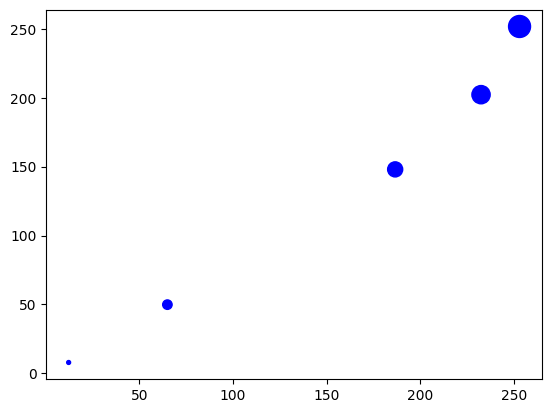

In [176]:
cluster_centroids = kmeans.cluster_centers_
print(cluster_centroids.shape)

plt.scatter(cluster_centroids[:,0], cluster_centroids[:,1], cluster_centroids[:,2], c='blue', marker='o')
plt.show()

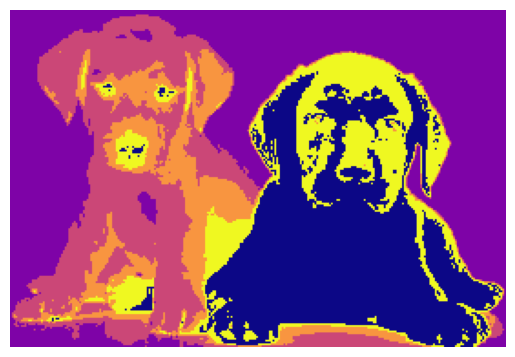

In [177]:
#4 Predict the cluster label of every pixel in the image and plot it back as an image.

cluster_labels = kmeans.predict(reshaped)          # print(kmeans.labels_) also produces the same as same data used to train the model is given

clustered_img_array = cluster_labels.reshape(img_array.shape[:2])

plt.imshow(clustered_img_array, cmap='plasma')
plt.axis('off')
plt.show()

dogs. jpeg

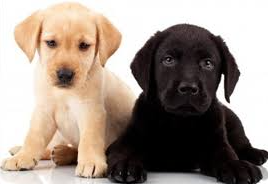

In [178]:
#5 Find out the three dominant colors in the image.
# [Hint: The cluster centers should correspond to three dominant colors]

dominant_colors = kmeans.cluster_centers_
print(f'Dominant colors are:\n', np.round(dominant_colors,2))
dominant_colors.shape

Dominant colors are:
 [[ 12.31   7.89   7.9 ]
 [252.99 251.72 249.95]
 [232.43 202.23 172.84]
 [186.6  148.02 117.75]
 [ 65.02  49.86  46.27]]


(5, 3)

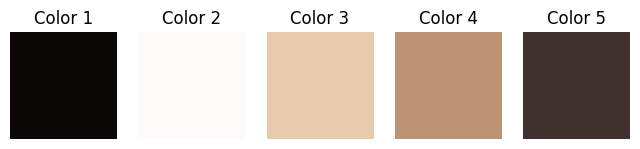

In [179]:
# dominant colors visual

plt.figure(figsize=(8, 2))
for i, color in enumerate(dominant_colors):
    plt.subplot(1, 5, i+1)
    plt.imshow([[color.astype(int)]])       # [[color/255]] also works - normalization values btn range 0-1 [[color.astype(int)]]
    plt.title(f"Color {i+1}")
    plt.axis('off')
plt.show()

In [180]:
# cluster labels explore

df = pd.DataFrame(cluster_labels)
df.value_counts()

0
1    17178
0    12237
2     9635
4     6132
3     5138
Name: count, dtype: int64